# Credit Card Defaulters

Objective: Develop Binary Classification Model to Predict possibility for a given customer become a defaulter for credit card payment

In [1]:
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../resource/source/UCI_Credit_Card.csv")
# read the dataset

In [3]:
df.head(2)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1


In [4]:
df.shape

(30000, 25)

In [5]:
df.drop('ID',axis=1,inplace=True)

In [6]:
columns = df.columns.tolist()

In [7]:
print(columns)

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_0                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   300

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [10]:
duplicates = df.duplicated().sum()
print("Duplicate Records Count:", duplicates)

Duplicate Records Count: 35


In [11]:
df[df.duplicated()]

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
1980,150000.0,2,1,1,38,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4585,150000.0,2,1,1,31,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6022,210000.0,2,1,2,39,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6466,210000.0,2,2,1,49,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
7319,500000.0,1,1,1,43,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
8320,360000.0,1,2,1,41,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
10250,50000.0,1,2,2,26,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
13106,360000.0,2,1,1,49,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
14294,20000.0,1,2,2,24,2,2,4,4,4,...,1650.0,1650.0,1650.0,0.0,0.0,0.0,0.0,0.0,0.0,1
15458,160000.0,1,2,2,28,-2,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [12]:
df.drop_duplicates(inplace=True)
# drop duplicates

In [13]:
df.shape
# rows and columns after duplicate drops

(29965, 24)

In [14]:
df.isna().sum()
# missing values

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [15]:
df.nunique()

LIMIT_BAL                        81
SEX                               2
EDUCATION                         7
MARRIAGE                          4
AGE                              56
PAY_0                            11
PAY_2                            11
PAY_3                            11
PAY_4                            11
PAY_5                            10
PAY_6                            10
BILL_AMT1                     22723
BILL_AMT2                     22346
BILL_AMT3                     22026
BILL_AMT4                     21548
BILL_AMT5                     21010
BILL_AMT6                     20604
PAY_AMT1                       7943
PAY_AMT2                       7899
PAY_AMT3                       7518
PAY_AMT4                       6937
PAY_AMT5                       6897
PAY_AMT6                       6939
default.payment.next.month        2
dtype: int64

In [16]:
basic_info = pd.DataFrame({
    "data_Types": df.dtypes.astype(str),
    "unique" : df.nunique(),
    "missing": df.isna().sum()
})
basic_info

,data_Types,unique,missing
LIMIT_BAL,float64,81,0
SEX,int64,2,0
EDUCATION,int64,7,0
MARRIAGE,int64,4,0
AGE,int64,56,0
PAY_0,int64,11,0
PAY_2,int64,11,0
PAY_3,int64,11,0
PAY_4,int64,11,0
PAY_5,int64,10,0


In [17]:
target = "default_payment_next_month"

In [18]:
df.rename(columns={'default.payment.next.month': target}, inplace=True)

In [19]:
columns = df.columns.tolist()

In [20]:
df[target].value_counts()

default_payment_next_month
0    23335
1     6630
Name: count, dtype: int64

default_payment_next_month
0    23335
1     6630
Name: count, dtype: int64


Text(0, 0.5, 'Count')

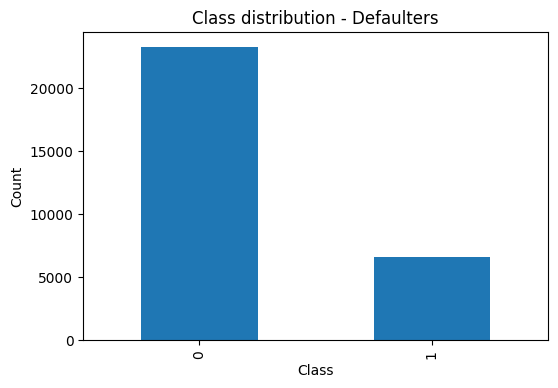

In [21]:
class_counts = df[target].value_counts().sort_index()
print(class_counts)
ax = class_counts.plot(kind='bar', title='Class distribution - Defaulters', figsize=(6,4))
ax.set_xlabel('Class'); ax.set_ylabel('Count')

In [22]:
from matplotlib import pyplot as plt
import seaborn as sns

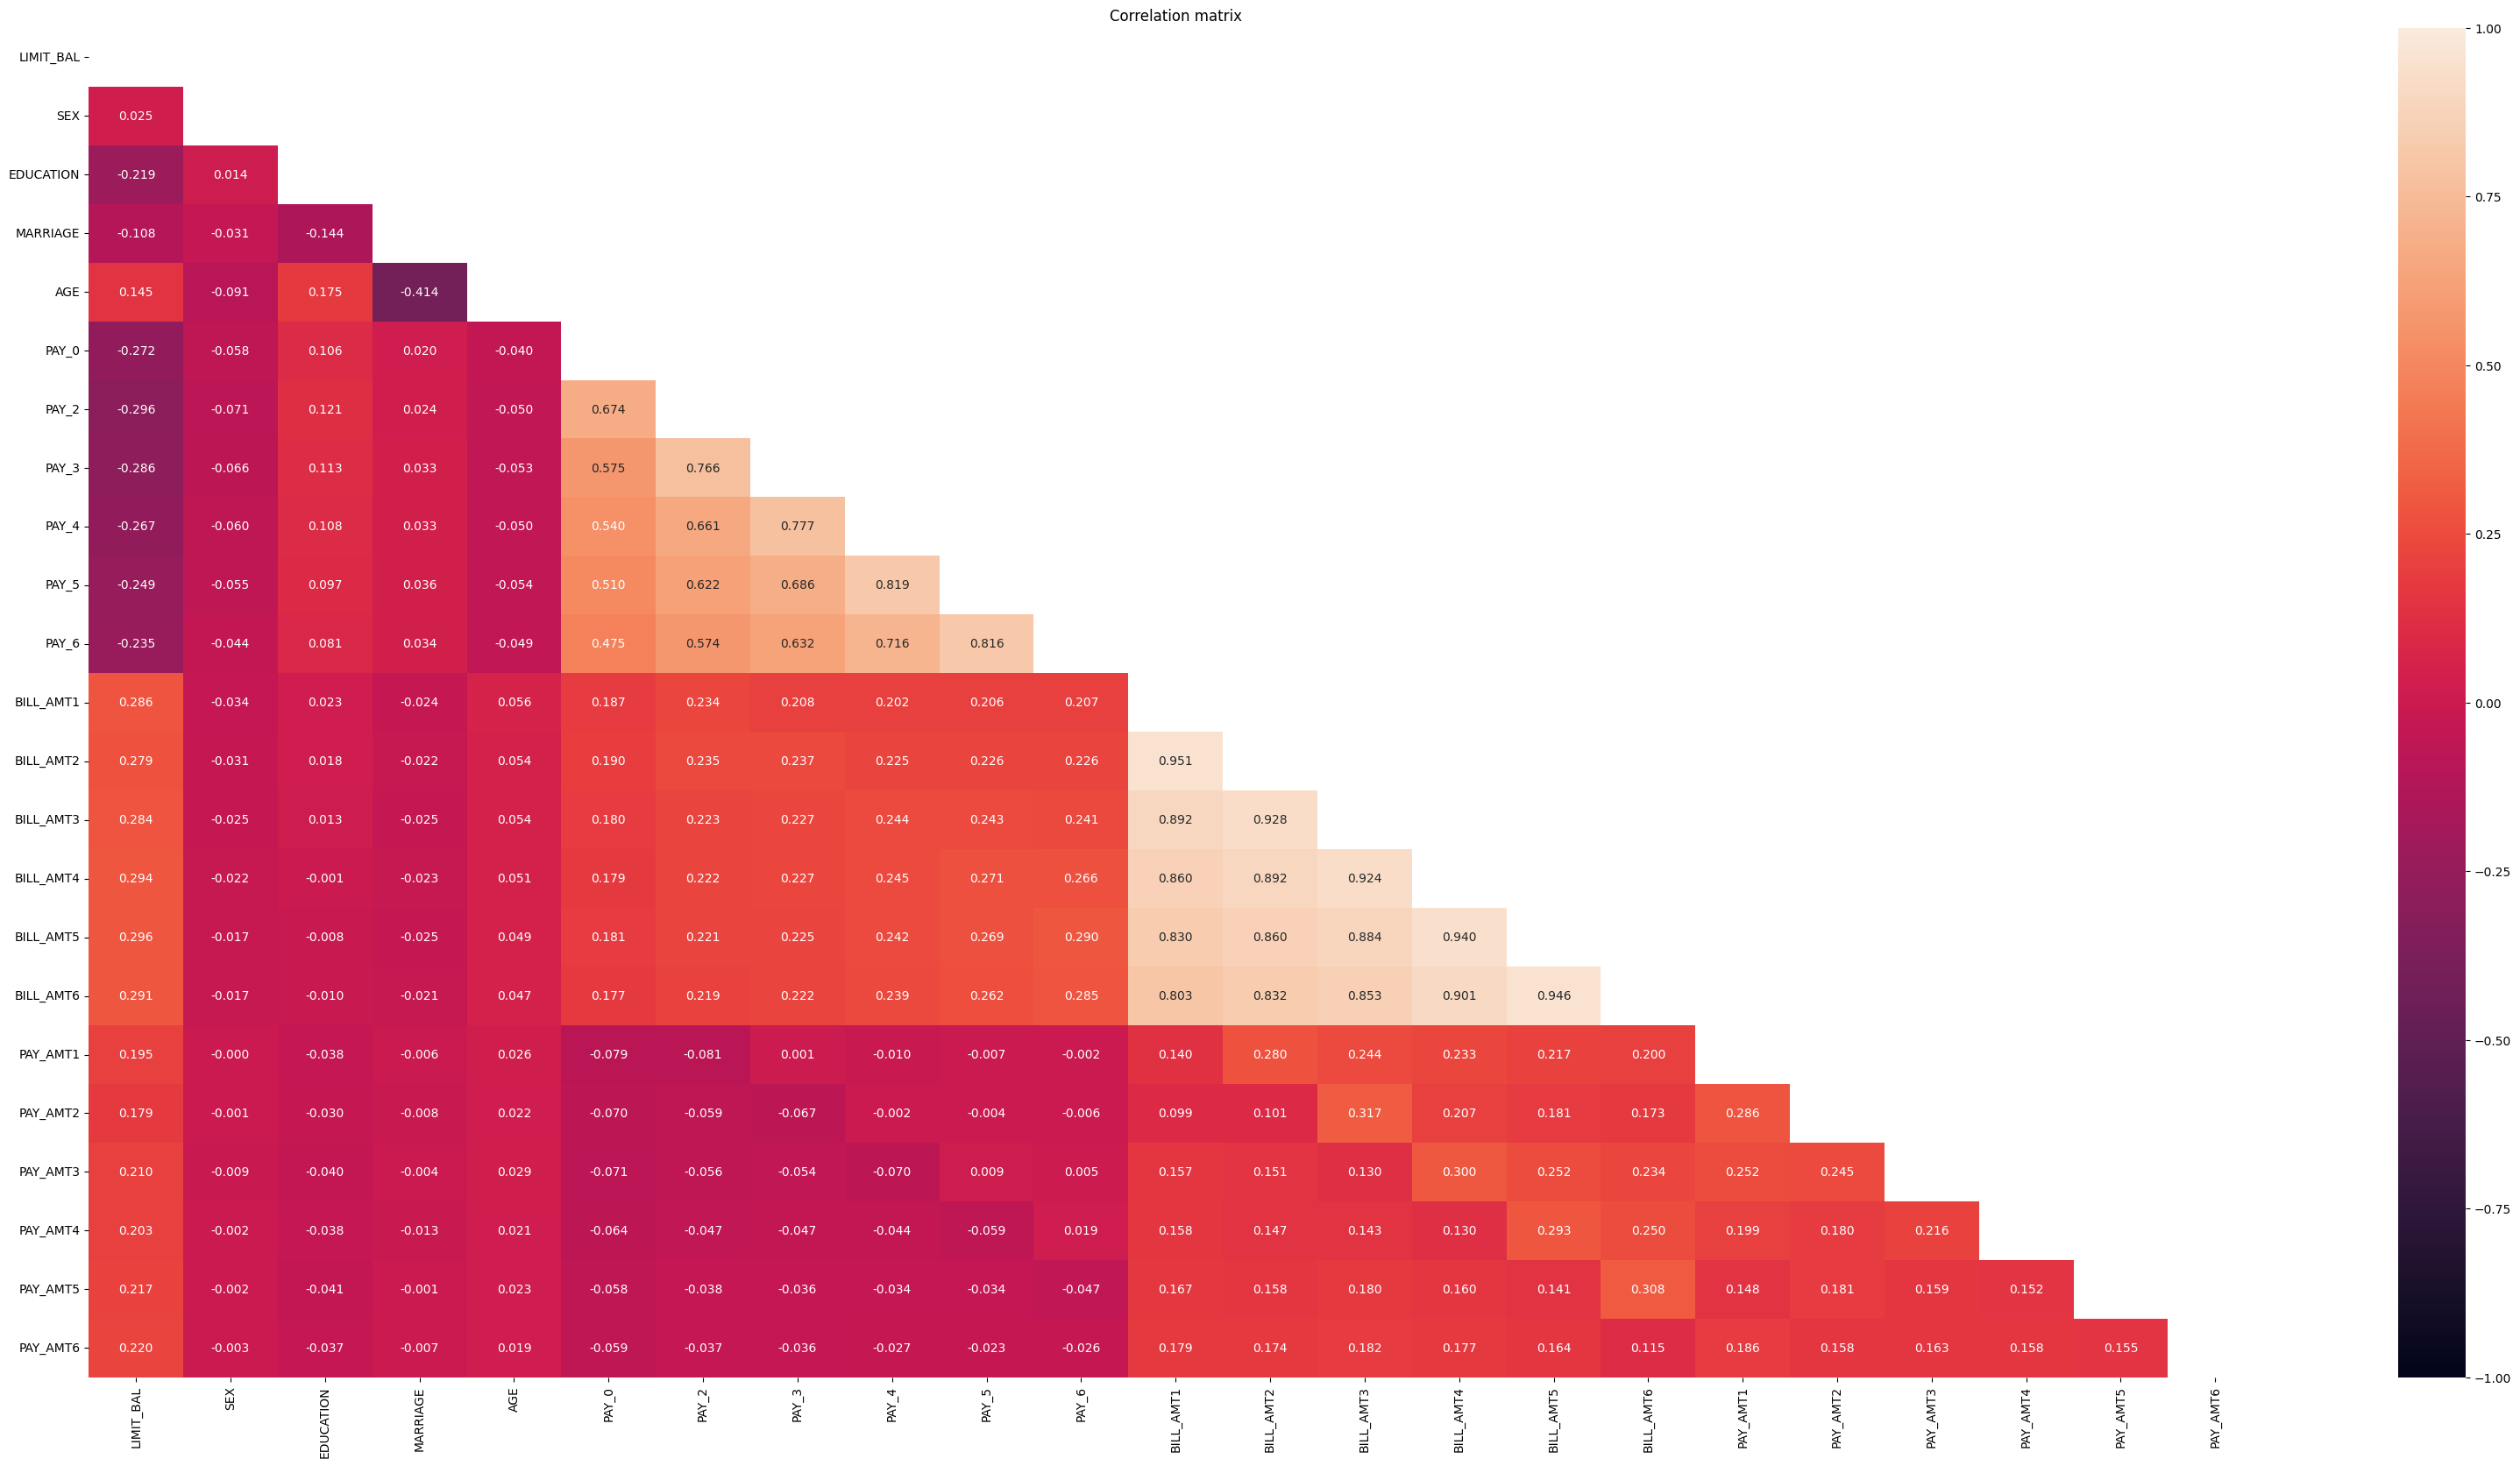

In [23]:
plt.figure(figsize=(40,20))
num_df = df.select_dtypes(include=[np.number]).drop(columns=target)
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', vmin=-1, vmax=1)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Correlation matrix')
plt.show()

In [24]:
unique_counts_per_columns = {}
for col in columns:
    unique_counts_per_columns[col] = df[col].value_counts().shape[0]

In [25]:
unq_cnt_df = pd.DataFrame( unique_counts_per_columns, ["unique_counts_column"]).transpose()

In [26]:
unq_cnt_df
# find unique values counts in each feature

,unique_counts_column
LIMIT_BAL,81
SEX,2
EDUCATION,7
MARRIAGE,4
AGE,56
PAY_0,11
PAY_2,11
PAY_3,11
PAY_4,11
PAY_5,10


In [27]:
# validating no categorical columns
category_columns = [col for col in columns if col not in columns]
category_columns

[]

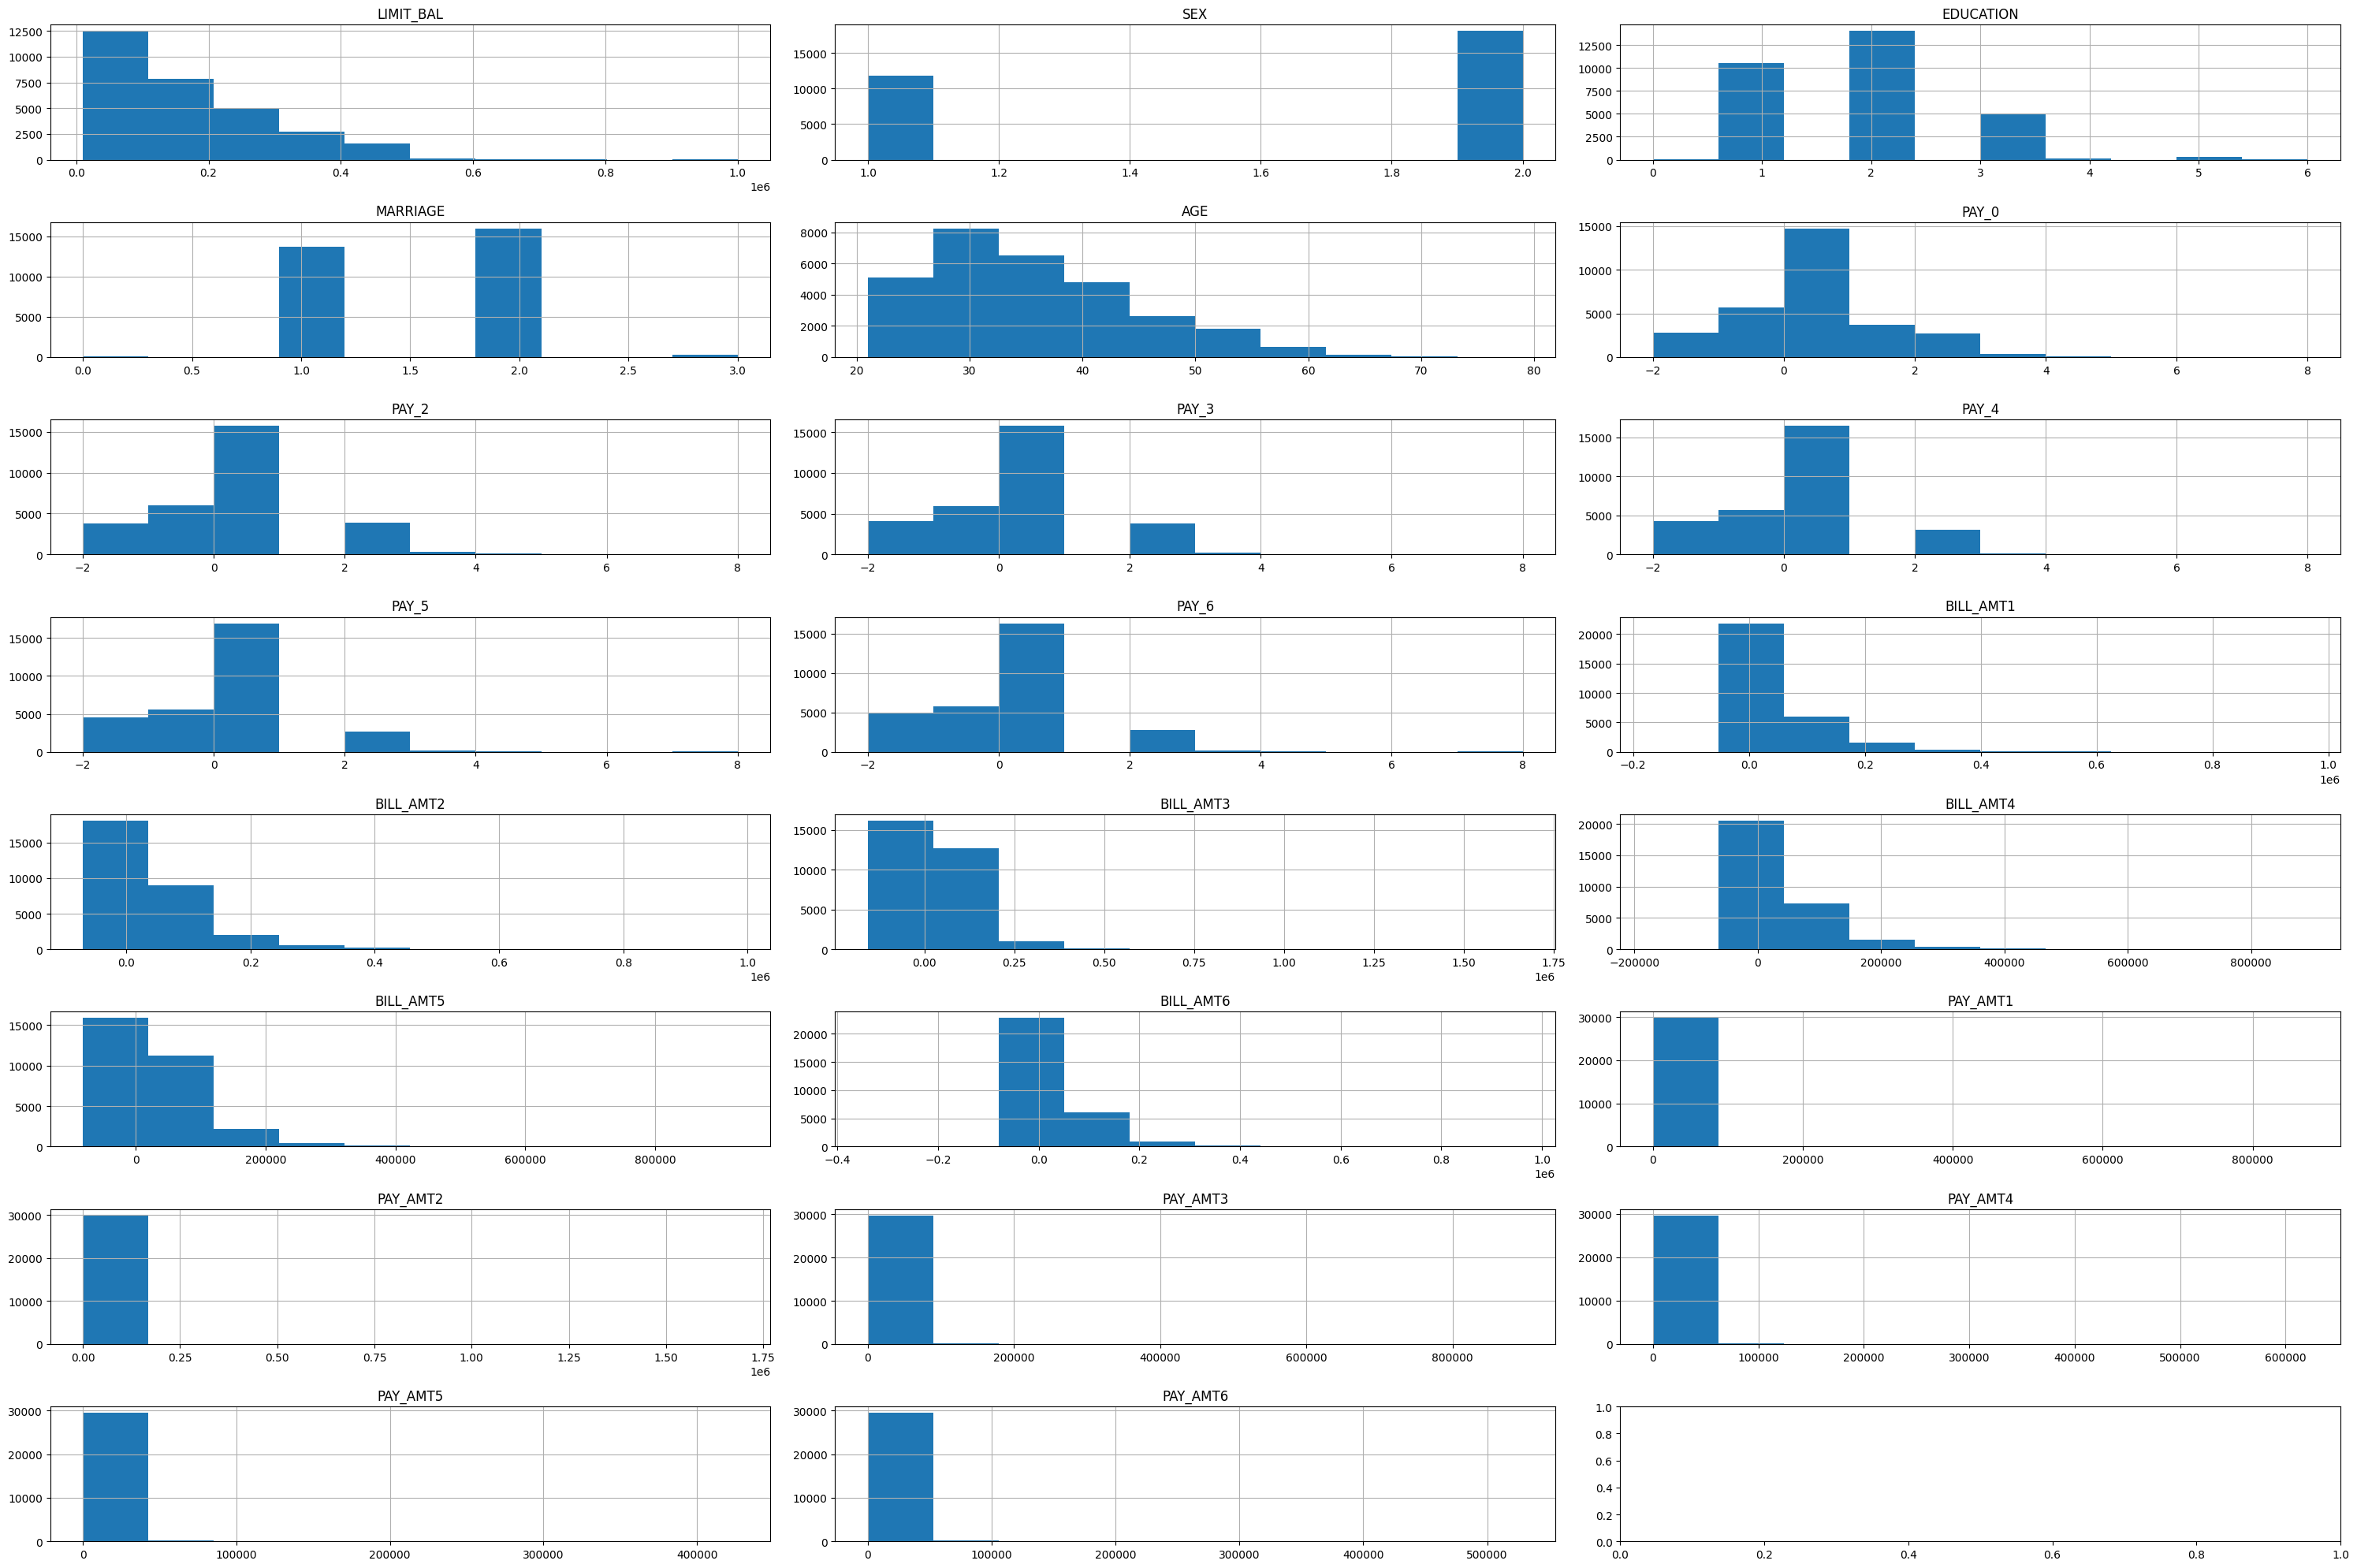

In [28]:
plot_cols = columns[:23]
fig, axes = plt.subplots(nrows=(len(plot_cols)+3)//3, ncols=3, figsize=(30, 20))
axes = axes.flatten()
for i, c in enumerate(plot_cols):
    ax = axes[i]
    df[c].hist(ax=ax, bins=10)
    ax.set_title(c)
plt.tight_layout()

In [29]:
df.head(2)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1


In [30]:
import re
bill_columns = [col for col in columns if re.match("BILL_A",col)]
payment_amount_columns = [col for col in columns if re.match('PAY_A',col)]

In [31]:
bill_columns

['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

In [32]:
payment_amount_columns

['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

In [33]:
def feature_add(df):
    df_copy = df.copy()
    bill_columns = [col for col in columns if re.match("BILL_A",col)]
    payment_amount_columns = [col for col in columns if re.match('PAY_A',col)]
    df_copy['avg_bill_amount'] = df[bill_columns].mean(axis=1)
    df_copy['avg_payment_amount'] = df[payment_amount_columns].mean(axis=1)
    return df_copy

In [34]:
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,3,1,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,3,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,2,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,3,1,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [35]:
df_new = feature_add(df)

In [36]:
df_new

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month,avg_bill_amount,avg_payment_amount
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,1284.000000,114.833333
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,2846.166667,833.333333
2,90000.0,2,2,2,34,0,0,0,0,0,...,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,16942.166667,1836.333333
3,50000.0,2,2,1,37,0,0,0,0,0,...,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,38555.666667,1398.000000
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,18223.166667,9841.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,3,1,39,0,0,0,0,0,...,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0,120891.500000,7091.666667
29996,150000.0,1,3,2,43,-1,-1,-1,-1,0,...,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0,3530.333333,2415.000000
29997,30000.0,1,2,2,37,4,3,2,-1,0,...,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1,11749.333333,5216.666667
29998,80000.0,1,3,1,41,1,-1,0,0,0,...,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1,44435.166667,24530.166667


In [37]:
df = df_new.copy()

In [38]:
df.shape

(29965, 26)

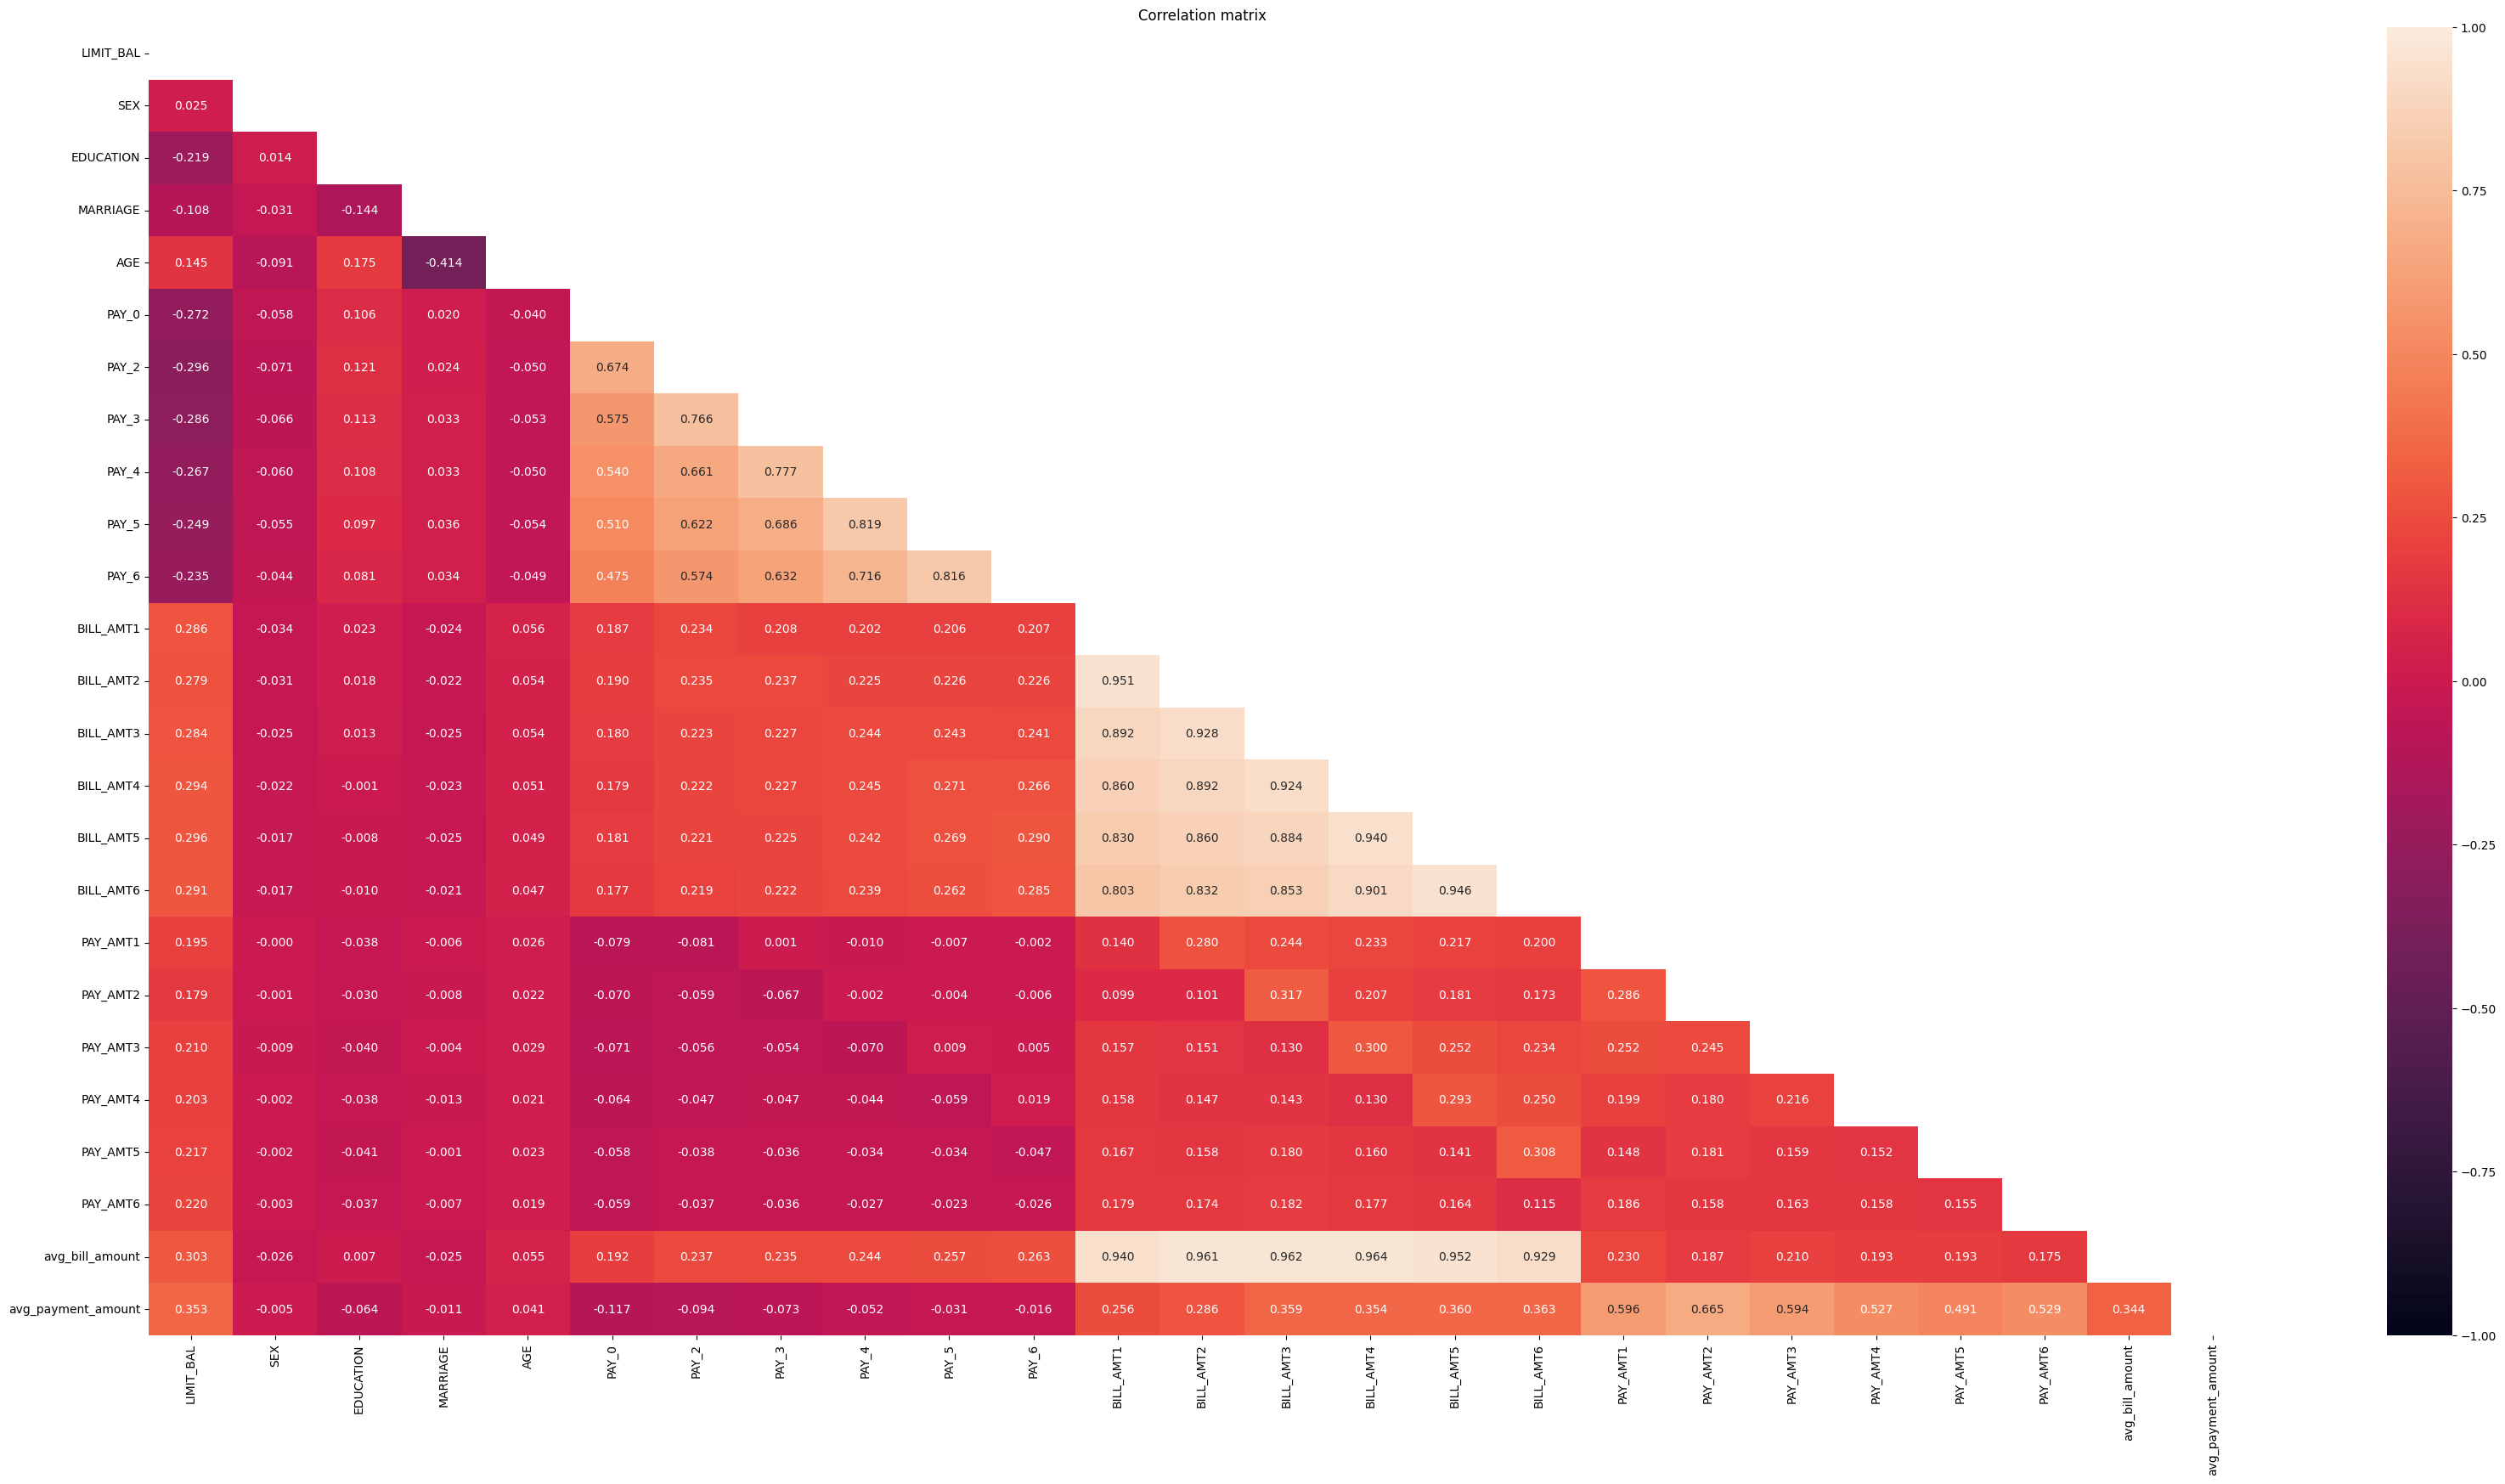

In [40]:
plt.figure(figsize=(40,20))
num_df = df.select_dtypes(include=[np.number]).drop(columns=target)
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', vmin=-1, vmax=1)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Correlation matrix')
plt.show()

In [41]:
df.columns.tolist()

['LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default_payment_next_month',
 'avg_bill_amount',
 'avg_payment_amount']

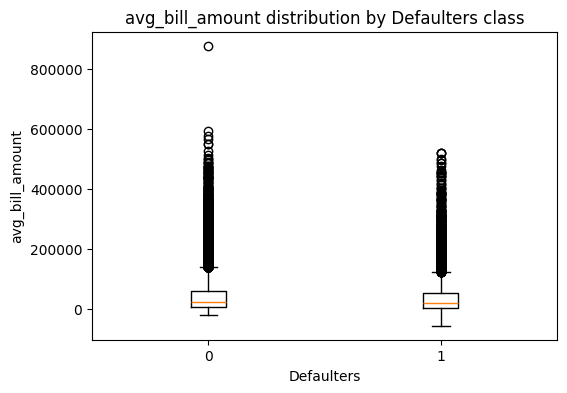

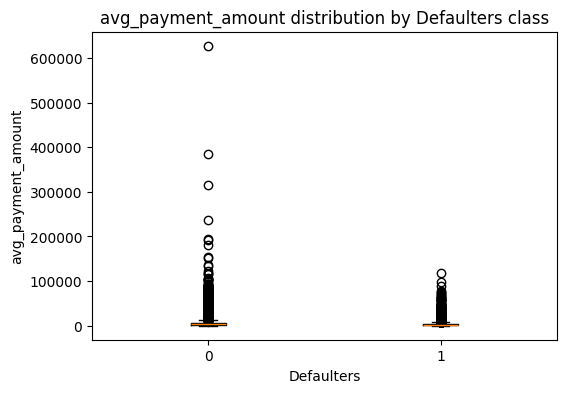

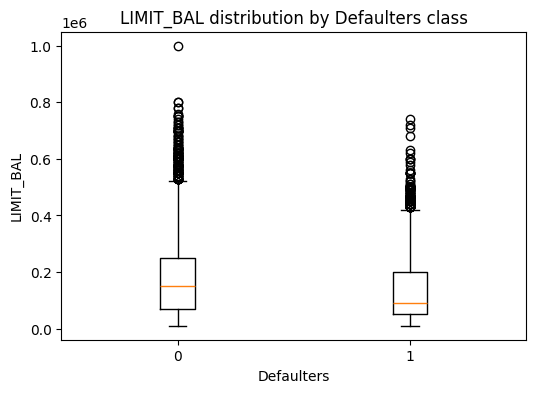

In [42]:
# Boxplots for key continuous features by class
key_features = ['avg_bill_amount', 'avg_payment_amount', 'LIMIT_BAL', 'Age']
for feat in key_features:
    if feat in df.columns:
        plt.figure(figsize=(6,4))
        data_to_plot = [df.loc[df[target]==cls, feat].dropna() for cls in sorted(df[target].unique())]
        plt.boxplot(data_to_plot, tick_labels=[str(x) for x in sorted(df[target].unique())])
        plt.title(f"{feat} distribution by Defaulters class")
        plt.xlabel("Defaulters")
        plt.ylabel(feat)
        plt.show()

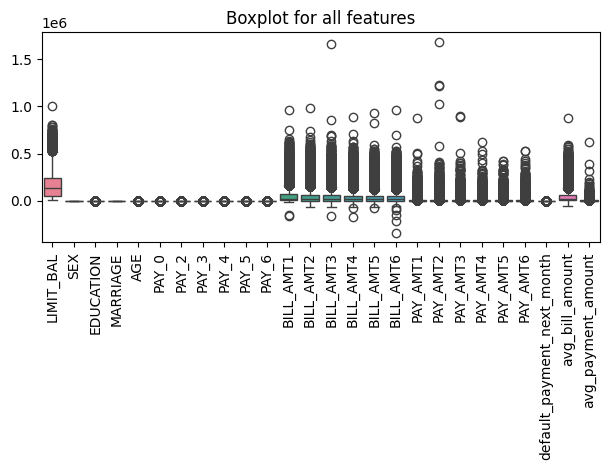

In [43]:
sns.boxplot(data=df)
plt.title("Boxplot for all features")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [44]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import matplotlib.pyplot as plt
from collections import OrderedDict

In [45]:

X = df.drop(columns=[target])
y = df[target].astype(int)

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [48]:
y_test.value_counts()

default_payment_next_month
0    4667
1    1326
Name: count, dtype: int64

In [49]:
y_train.value_counts()

default_payment_next_month
0    18668
1     5304
Name: count, dtype: int64

In [50]:
pct_y_train = y_train.value_counts(normalize=True) * 100
pct_y_test = y_test.value_counts(normalize=True) * 100

In [51]:
pct_y_train

default_payment_next_month
0    77.874187
1    22.125813
Name: proportion, dtype: float64

In [52]:
pct_y_test

default_payment_next_month
0    77.874187
1    22.125813
Name: proportion, dtype: float64

# Data Split is moderatly good, hence undersampling technique does not really needed to apply

In [61]:
from sklearn.linear_model import LogisticRegression

In [62]:
baseline = LogisticRegression(max_iter=2000, random_state=42)
baseline.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [63]:
value = baseline.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(5993,))

In [66]:
value.

np.False_

In [67]:
y_proba_base = baseline.predict_proba(X_test)[:, 1]

In [68]:
y_proba_base

array([0.22904474, 0.23519987, 0.24159707, ..., 0.27441893, 0.20538054,
       0.24365948], shape=(5993,))

In [69]:
from sklearn.metrics import roc_auc_score, average_precision_score

print("ROC AUC:", roc_auc_score(y_test, y_proba_base))
print("PR AUC :", average_precision_score(y_test, y_proba_base))

ROC AUC: 0.7113619227585877
PR AUC : 0.4798442256838866


In [70]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)


In [71]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [76]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [77]:
y_pred_scaled = model.predict(X_test_scaled)
y_pred_proba_scaled = model.predict_proba(X_test_scaled)[:, 1]


In [78]:
from sklearn.metrics import roc_auc_score, average_precision_score

print("Scaled ROC AUC:", roc_auc_score(y_test, y_pred_proba_scaled))
print("Scaled PR AUC :", average_precision_score(y_test, y_pred_proba_scaled))

Scaled ROC AUC: 0.7158103768282873
Scaled PR AUC : 0.5040332311968886


In [82]:
print("Accuracy:", accuracy_score(y_test, value))
print("Precision:", precision_score(y_test, value))
print("Recall:", recall_score(y_test, value))
print("F1-score:", f1_score(y_test, value))
print("ROC-AUC:", roc_auc_score(y_test, value))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, value))
print("\nClassification Report:\n", classification_report(y_test, value))


Accuracy: 0.7962623060236943
Precision: 0.723404255319149
Recall: 0.1282051282051282
F1-score: 0.21780909673286356
ROC-AUC: 0.5571387758017284

Confusion Matrix:
 [[4602   65]
 [1156  170]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.99      0.88      4667
           1       0.72      0.13      0.22      1326

    accuracy                           0.80      5993
   macro avg       0.76      0.56      0.55      5993
weighted avg       0.78      0.80      0.74      5993



In [83]:
print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print("Precision:", precision_score(y_test, y_pred_scaled))
print("Recall:", recall_score(y_test, y_pred_scaled))
print("F1-score:", f1_score(y_test, y_pred_scaled))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_scaled))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_scaled))
print("\nClassification Report:\n", classification_report(y_test, y_pred_scaled))


Accuracy: 0.8132821625229434
Precision: 0.7284768211920529
Recall: 0.248868778280543
F1-score: 0.37099494097807756
ROC-AUC: 0.6112567589709978

Confusion Matrix:
 [[4544  123]
 [ 996  330]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.97      0.89      4667
           1       0.73      0.25      0.37      1326

    accuracy                           0.81      5993
   macro avg       0.77      0.61      0.63      5993
weighted avg       0.80      0.81      0.78      5993



In [84]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coefficients)


               Feature  Coefficient
5                PAY_0     0.648627
12           BILL_AMT2     0.264886
6                PAY_2     0.110433
16           BILL_AMT6     0.094621
7                PAY_3     0.083287
4                  AGE     0.057236
8                PAY_4     0.033433
9                PAY_5     0.026156
15           BILL_AMT5     0.016409
13           BILL_AMT3     0.009651
19            PAY_AMT3     0.006046
10               PAY_6     0.003344
22            PAY_AMT6    -0.000896
14           BILL_AMT4    -0.019913
23     avg_bill_amount    -0.020830
21            PAY_AMT5    -0.021826
1                  SEX    -0.048342
20            PAY_AMT4    -0.058882
3             MARRIAGE    -0.078172
2            EDUCATION    -0.093850
0            LIMIT_BAL    -0.105718
24  avg_payment_amount    -0.132424
18            PAY_AMT2    -0.141209
17            PAY_AMT1    -0.222679
11           BILL_AMT1    -0.446777
